# What LiteLLM is

## Facade & Adapter

1. Present **Single & Simple Interface** (OpenAI format I/F).
2. **Coordinate Multiple Backend** LLMs.
3. Adapt to each Backend (convert OpenAI format to their formats).

```
                ┌───────────────────┐
App A, B, C ──► │                   │ ───► OpenAI
                │ LiteLLM SDK/Proxy │ ───► Anthropic
                │                   │ ───► Bedrock
                └───────────────────┘ ...
```
Why adapter?  
Adapter is **Conversion and Connect**. LiteLLM accept single I/F format (OpenAI) and convert to backend formats.

* [LiteLLM - Getting Started](https://docs.litellm.ai/docs/)
* [LiteLLM Cookbook](https://github.com/BerriAI/litellm/tree/main/cookbook)

# Setup

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import os
import json
import operator
from typing import (
    List, Dict, Any, Literal, Optional, Callable, Annotated
)

import regex as re
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langgraph.graph import StateGraph, START, END
import litellm
import mdformat
import trafilatura
from IPython.display import Markdown

## API Keys

In [3]:
path_to_openai_key:str = os.path.expanduser('~/.openai/api_key')
with open(path_to_openai_key, 'r', encoding='utf-8') as file:
    os.environ["OPENAI_API_KEY"] = file.read().strip()

path_to_tavily_key:str = os.path.expanduser('~/.tavily/api_key')
with open(path_to_tavily_key, 'r', encoding='utf-8') as file:
    os.environ["TAVILY_API_KEY"] = file.read().strip()

## Models

In [4]:
MODEL: str = "openai/gpt-4o"

---
# LiteLLM Facade - Chat/Completion

LiteLLM still uses Open AI deprecated Chat Completion API format.

* [LiteLLM API Reference - Chat Completions - POST
/chat/completions](https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create)

> Creates a model response for the given chat conversation. Learn more in the text generation, vision, and audio guides. Returns a chat completion object, or a streamed sequence of chat completion chunk objects if the request is streamed.
> 
> **Returns:** <br>
> ```
> ChatCompletion = object { id, choices, created, 5 more }: Represents a chat completion response returned by model, based on the provided input.
> ```


In [5]:
def call_llm(
    messages: List[Dict[str, Any]],
    tools: Optional[List[Dict[str, Any]]] = None,
    stream: bool = False,
    model=MODEL,
):
    try:
        # responses is generator
        response = litellm.completion(
            model=model,
            messages=messages,
            tools=tools,
            stream=stream
        )
        return response
    except litellm.AuthenticationError as e:
        print(f"Authentication failed: {e}")
    except litellm.RateLimitError as e:
        print(f"Rate limited: {e}")
    except litellm.APIError as e:
        print(f"API error: {e}")

## Batch

In constrat to **streaming**, send a one-off request to get one-off reply.

In [6]:
response: Dict[str, Any] = call_llm(messages=[{
    "role": "user",
    "content": "Hello, how are you?"
}])
print(json.dumps(response.model_dump(), indent=4, default=str))
del response

{
    "id": "chatcmpl-DM8MdmLEFHRN5NILGmOvz6QJ8RnjC",
    "created": 1774167739,
    "model": "gpt-4o-2024-08-06",
    "object": "chat.completion",
    "system_fingerprint": "fp_e6c36a96dd",
    "choices": [
        {
            "finish_reason": "stop",
            "index": 0,
            "message": {
                "content": "Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you with whatever you need. How can I assist you today?",
                "role": "assistant",
                "tool_calls": null,
                "function_call": null,
                "provider_specific_fields": {
                    "refusal": null
                },
                "annotations": []
            },
            "provider_specific_fields": {}
        }
    ],
    "usage": {
        "completion_tokens": 34,
        "prompt_tokens": 13,
        "total_tokens": 47,
        "completion_tokens_details": {
            "accepted_prediction_tokens": 0,
      

## Streaming

In [7]:
response: Dict[str, Any] = call_llm(
    messages=[{
        "role": "user", "content": "Hello, how are you?"
    }],
    stream=True
)

# Iterate through the generator
for chunk in response:
    # Extract the content delta
    content = chunk.choices[0].delta.content
    
    if content:
        # print(..., end="", flush=True) creates the typewriter effect
        print(content, end="", flush=True)
        
print() # Print a newline when the stream finishes    
del response

Hello! I’m just a computer program, so I don’t have feelings, but I’m here and ready to help you. How can I assist you today?


---
# Tool Calling Protocol


## OpenAI API Specification


OpenAI defined the **Function (Tool) Calling Protocol** as in [Function calling](https://developers.openai.com/api/docs/guides/function-calling). 

  1. LLM responds with role: "assistant" message containing tool_calls (with id, function.name, function.arguments)
  2. You execute the tools                                                      
  3. You send back one message per tool call with role: "tool", tool_call_id matching the original id, and content containing the result as a string

There are six stages in the Protocol.

1. Tool Definition by Application and Declaration to LLM at Prompt Message
> When we make an API request to the model with a prompt, we can include a list of tools the model could consider using.

2. Tool Call Decision by LLM  (**Reasoing** and **Decisoning**)
> tool call refers to a special kind of decision response from LLM to call one of the tools to execute the prompt given.
   
3. Tool Execution by Application
4. Tool Output Usage by LLM
> tool call output refers to the response a tool generates using the input from a model’s tool call. We send **all of the tool definition, the original prompt, the model’s tool call, and the tool call output back** to LLM to finally receive a text response.

5. LLM completes the prompt

### Tool Calling Workflow

```
1. Application to LLM
   │ Define and Declare Tools in the prompt
   ▼
2. LLM
   │ Reason/Decide Tool Calls
   ▼
3. Application/Orchestration
   │ Tool Executions
   ▼
4. LLM Receives Tool Outputs
   │ Use Tool Outputs
   ▼
5. LLM Complete the prompt
```

<img src="image/tool_call_flow.png" align="left" width=500/>



## LiteLLM 

Use LiteLLM as the wrapper for OpenAI Specification for Function calling.

* [LiteLLM - Function Calling](https://docs.litellm.ai/docs/completion/function_call)

1. litellm.completion() with tools set to get_current_weather
2. Parse the Model Response and Execute Functions
3. Second litellm.completion() call

## Tool Definition

* [Defining Functions (Tools)](https://developers.openai.com/api/docs/guides/function-calling#defining-functions)

First, you define a tool based on the OpenAI definition. This is what LiteLLM accepts as well.

| Field       | Description                                          |
|-------------|------------------------------------------------------|
| type        | This should always be function                       |
| name        | The function’s name (e.g. get_weather)               |
| description | Details on when and how to use the function          |
| parameters  | JSON schema defining the function’s input arguments  |
| strict      | Whether to enforce strict mode for the function call |


### Tool Definition Format

The format of a tool definition:

```
tool_definition := {
  "type": "function",
  "function": {
     "name": "...",
     "description": "...",
     "parameters": { JSON schema }   # <--- Pydantic can generate
  }
}
```

**Example:**
```
{
  "type": "function",
  "name": "get_weather",
  "description": "Retrieves current weather for the given location.",
  "parameters": {
    "type": "object",
    "properties": {
      "location": {
        "type": "string",
        "description": "City and country e.g. Bogotá, Colombia"
      },
      "units": {
        "type": "string",
        "enum": ["celsius", "fahrenheit"],
        "description": "Units the temperature will be returned in."
      }
    },
    "required": ["location", "units"],
    "additionalProperties": false
  },
  "strict": true
}
```

### Namespace

* [Defining namespace](https://developers.openai.com/api/docs/guides/function-calling#defining-namespaces)

> Namespaces help organize similar tools and are especially useful when the model must choose between tools that serve different systems or purposes, such as one search tool for your CRM and another for your support ticketing system

```
{
  "type": "namespace",
  "name": "crm",
  "description": "CRM tools for customer lookup and order management.",
  "tools": [
      tool_definition+
 ]
}
```

### Tool Parameter JSON Schema

[Pydantic JSON Schema](https://docs.pydantic.dev/latest/concepts/json_schema/) to generate the JSON Schema for the Tool Definition. 

For the Tool Definition for the [Tavilty Search](https://docs.tavily.com/sdk/python/reference#tavily-search):


#### Tool 

In [8]:
# Function for the Search Tool
search_tool: Callable = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
if not hasattr(search_tool, "tool_name"):
    search_tool.name = "search_tool"

name_to_tool: Dict[str, Callable] = {
    # search_tool.name: search_tool.search
    search_tool.name: search_tool.search
}

#### Tool Parameters

Use Pydantic to generate the JSON Schema for the parameters.

In [9]:
# Parameters for the Search Tool
class SearchToolParameters(BaseModel):
    """
    Search the web for current events, news, or deep research.
    """
    query: str = Field(description="The search query to look up")
    
    topic: Literal["general", "news", "finance"] = Field(
        default="general",
        description="Category of search. Use 'news' for current events/politics, 'finance' for market data."
    )
    
    search_depth: Literal["basic", "advanced"] = Field(
        default="basic",
        description="Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context."
    )
    
    time_range: Optional[Literal["day", "week", "month", "year"]] = Field(
        default=None,
        description="Filter results by publication date. Especially useful with topic='news'."
    )
    
    max_results: int = Field(
        default=5, ge=1, le=10,
        description="Number of search results to return."
    )

In [10]:
search_tool_parameters: Dict[str, Any] = SearchToolParameters.model_json_schema()
print(json.dumps(search_tool_parameters, indent=2, default=str))

{
  "description": "Search the web for current events, news, or deep research.",
  "properties": {
    "query": {
      "description": "The search query to look up",
      "title": "Query",
      "type": "string"
    },
    "topic": {
      "default": "general",
      "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
      "enum": [
        "general",
        "news",
        "finance"
      ],
      "title": "Topic",
      "type": "string"
    },
    "search_depth": {
      "default": "basic",
      "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
      "enum": [
        "basic",
        "advanced"
      ],
      "title": "Search Depth",
      "type": "string"
    },
    "time_range": {
      "anyOf": [
        {
          "enum": [
            "day",
            "week",
            "month",
            "year"
          ],
          "type": "string"
        },
        {
       

#### Tool Description

In [11]:
search_tool_description: str = SearchToolParameters.__doc__.strip()
print(search_tool_description)

Search the web for current events, news, or deep research.


### Tool Definition of the Tabiliy Web Search

In [12]:
search_tool_definition = {
    "type": "function",
    "function": {
        "name": search_tool.name,
        "description": search_tool_description,
        "parameters": search_tool_parameters
    }
}
print(json.dumps(search_tool_definition, indent=2, default=str))

{
  "type": "function",
  "function": {
    "name": "search_tool",
    "description": "Search the web for current events, news, or deep research.",
    "parameters": {
      "description": "Search the web for current events, news, or deep research.",
      "properties": {
        "query": {
          "description": "The search query to look up",
          "title": "Query",
          "type": "string"
        },
        "topic": {
          "default": "general",
          "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
          "enum": [
            "general",
            "news",
            "finance"
          ],
          "title": "Topic",
          "type": "string"
        },
        "search_depth": {
          "default": "basic",
          "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
          "enum": [
            "basic",
            "advanced"
          ],
         

## Tool Declaration

You declare the **tool definitions** to the LLM.

```
tools = [
    {
      "type": "function",
      "function": {
        "name": "SearchTool",
        "description": "...",
        "parameters": { JSON Schema }
      }
    },
    ...
]
```

* [OpenAI Create chat completion API](https://developers.openai.com/api/reference/python/resources/chat/subresources/completions/methods/create/#:~:text=Streaming-,Functions,-Logprobs) or [vLLM OpenAI Chat Completion Client With Tools](https://docs.vllm.ai/en/v0.7.2/getting_started/examples/openai_chat_completion_client_with_tools.html)

> tools: Optional[Iterable[ChatCompletionToolUnionParam]]<br>
> A list of tools the model may call. You can provide either [custom tools](https://platform.openai.com/docs/guides/function-calling#custom-tools) or [function tools](https://platform.openai.com/docs/guides/function-calling).

```
completion = client.chat.completions.create(
  model="VAR_chat_model_id",
  messages=messages,
  tools=tools,
  tool_choice="auto"
)
```

* [LiteLLM Function Calling](https://docs.litellm.ai/docs/completion/function_call)

```
response = litellm.completion(
    model=model,
    messages=messages,
    tools=tools,            # <---- Declare the LLM model the tools you can use
    tool_choice="auto"
)
```

*Example*

```
{
  "model": "gpt-4o",
  "messages": [
    {
        "role": "user",                   # <--- Beware of the "role" used
        "content": "Weather in Tokyo?"
    }
  ],
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "get_weather",
        "parameters": {
          "type": "object",
          "properties": {
            "location": {"type": "string"}
          }
        }
      }
    }
  ]
}
```

### Tool Declartion for the Search

In [13]:
tool_declarations: List[Dict[str, Any]] = [
    search_tool_definition
]

### Messages to LLM

Build the the messages to LLM, which is prompt.

In [14]:
messages_prompt: List[Dict[str, str]] = [
    {
        "role": "system", 
        "content": "You are a helpful assistant and advise tools to use to complete the request."
    },
    {
        "role": "user",      # <--- Beware of the "role" used
        "content": "What are the top news headlines in AI from the last week?"
    }
]

### LLM Call


In [15]:
try:
    # responses is generator
    response_to_prompt: Dict[str, Any] = litellm.completion(
        model=MODEL,
        messages=messages_prompt,
        tools=tool_declarations,
        stream=False
    )

except litellm.AuthenticationError as e:
    print(f"Authentication failed: {e}")
except litellm.RateLimitError as e:
    print(f"Rate limited: {e}")
except litellm.APIError as e:
    print(f"API error: {e}")

print(json.dumps(response_to_prompt.model_dump(), indent=4, default=str))

{
    "id": "chatcmpl-DM8MgypjtNSSQwEuUkdhfRAQ18cUz",
    "created": 1774167742,
    "model": "gpt-4o-2024-08-06",
    "object": "chat.completion",
    "system_fingerprint": "fp_49bd10b094",
    "choices": [
        {
            "finish_reason": "tool_calls",
            "index": 0,
            "message": {
                "content": null,
                "role": "assistant",
                "tool_calls": [
                    {
                        "function": {
                            "arguments": "{\"query\":\"top AI news\",\"topic\":\"news\",\"time_range\":\"week\",\"max_results\":5}",
                            "name": "search_tool"
                        },
                        "id": "call_uuh5m9fJIW2bEOQP1GbB82gl",
                        "type": "function"
                    }
                ],
                "function_call": null,
                "provider_specific_fields": {
                    "refusal": null
                },
                "annotations": 

## LLM Tool Calls

### Tool call handling logic

* [OpenAI - Handling function calls](https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls)

> The response output array contains an entry with the type having a value of function_call. Each entry with a call_id (used later to submit the function result), name, and JSON-encoded arguments.
> 
>``` 
> for tool_call in response.output:
>     if tool_call.type != "function_call":
>         continue
> 
>     name = tool_call.name
>     args = json.loads(tool_call.arguments)
> 
>     result = call_function(name, args)
>     input_messages.append({
>         "type": "function_call_output",
>         "call_id": tool_call.call_id,
>         "output": str(result)
>     })
>```



### Tool Calls

When the LLM decides that you should call a tool, LLM responds with ```role: "assistant"``` message containing ```tool_calls (id, function.name, function.arguments)```. There are multiple choices and each choice can have multiple tool calls.

The tool_call ```id``` is the **critical link between the application and LLM** to identify which tool call and exeuiton it handles.

```
"message": {
    "role": "assistant",                            # <--- Beware of the "role" used by LLM
    "tool_calls": [
        {
            "function": {
                "arguments": "{\"query\":\"AI news\",\"topic\":\"news\",\"search_depth\":\"basic\",\"time_range\":\"week\"}",
                "name": "search_tool"
            },
            "id": "call_JVHGxhAhxbmAlwiDkuc7fXk6",  # <--- Must be used between application and LLM
            "type": "function"
        }
    ],
}
```

In [16]:
assert "choices" in response_to_prompt.model_dump(), \
  f"Expected 'choices' in the response:\n{json.dumps(response_to_prompt, indent=2, default=str)}"

In [17]:
def extract_tool_call_messages(response: Dict[str, Any]) -> List[Dict[str, str]]:
    """Extract the tool calls requested by LLM
    Args:
        response: response from the LLM
    Returns: List of message for tool calls from LLM.
    """
    return [
        choice.get("message", {})
        for choice in response.model_dump().get("choices", [])
    ]

In [18]:
def execute_tool_calls(messages: List[Dict[str, str]]) -> List[Dict[str, str]]:
    """Execute tool calls requested by LLM.
    Args:
        messages: Messages for tool calls requests from LLM.
    Returns:
        messages_tool_outputs: 
            Tool output messages built from tool executions in the LiteLLM format.
            The messages are part of those to be sent back to LLM.
            The format for LiteLLM is [{
                "role": "tool",
                "tool_call_id": tool_call["id"],
                "name": func_name,
                "content": content
            }]
    """
    _messages_tool_outputs: List[Any] = []
    for _message in messages:
        for tool_call in _message.get('tool_calls', {}):
            if tool_call.get('type', '') != 'function':
                continue;

            func_name: str = tool_call['function']['name']
            func_args: Dict[str, str] = json.loads(tool_call['function']['arguments'])
            execution: Any = name_to_tool[func_name](**func_args)
            content = "\n".join([
                "Source: {}\nURL: {}\nContent: {}\n---".format(
                    r['title'],
                    r['url'],
                    # Fetch clean article text from URL; fall back to Tavily snippet
                    r['content']
                )
                for r in execution['results']
            ])
            _messages_tool_outputs.append({
                "role": "tool",
                "tool_call_id": tool_call["id"],
                "name": func_name,
                "content": content
            })

    return _messages_tool_outputs

In [29]:
def show_tool_executions(outputs: list) -> None:
    """Display tool execution results.
    Parses URL from each result block and fetches clean article text via trafilatura.
    Falls back to stored Tavily content if the URL is blocked/paywalled.
    """
    for msg in outputs:
        # Each content has multiple results separated by \n---\n
        # Format per block: "Source: ...\nURL: ...\nContent: ...\n---"
        for block in msg.get("content", "").split('\n---\n'):
            if not block.strip():
                continue
            source = url = article_content = ''
            for line in block.strip().splitlines():
                if line.startswith('Source: '):
                    source = line[len('Source: '):]
                elif line.startswith('URL: '):
                    url = line[len('URL: '):]
                elif line.startswith('Content: '):
                    article_content = line[len('Content: '):]
            
            # Fetch clean text from URL; fall back to Tavily snippet
            if url:
                fetched = trafilatura.extract(trafilatura.fetch_url(url))
                if fetched:
                    article_content = fetched
        
            display(Markdown(f"**{source}**\n\n{article_content.replace(chr(160), ' ')}"))
            display(Markdown('---'))

In [30]:
messages_tool_calls: List[Dict[str, Any]] = extract_tool_call_messages(response=response_to_prompt)
messages_tool_outputs: List[Dict[str, Any]] = execute_tool_calls(messages=messages_tool_calls)

In [31]:
show_tool_executions(outputs=messages_tool_outputs)

**iTnews Executive Retreat - Data & AI Edition - iTnews**

iTnews Executive Retreat - Data & AI Edition
A new event series designed to give senior technology executives the space to step back from day-to-day pressures and connect with peers in a focused, restorative environment.
The iTnews Executive Retreats bring together leaders from end-user organisations to reflect, share insights and explore the realities of technology and business leadership away from the demands of the office.
The Data & AI edition, taking place in May 2026, will consist of a curated group of at least 24 senior technology, data and AI leaders in Australian enterprise and government for an overnight stay at Château Élan in the Hunter Valley.
During the retreat, attendees will:
- Explore how AI and advanced data capabilities are reshaping technology leadership
- Share real-world approaches to scaling AI responsibly across the enterprise
- Discuss data strategy, governance and trust in an AI-driven environment
- Foster trusted peer-to-peer connections that extend beyond the retreat
Limited spots are available, so register your interest to join this exclusive retreat here.
Event Information:
Château Élan - Hunter Valley
Website
May 28 2026 10:00AM to May 29 2026 12:00PM
nextmedia takes no responsibility for the accuracy of the content contained in these listings.
Please contact the vendor with any enquiries.

---

**Studio Profit Report: Warner Bros. & Sony Rise, Paramount Is Rebuilding - TV News Check**

Broadcast Industry News - Television, Cable, On-demand. Home » Studio Profit Report: Warner Bros. # Studio Profit Report: Warner Bros. **This article was originally posted on hollywoodreporter.com**. ### Survey: Voters Trust TV News Over AI, Social & Search. ### NewsTechForum 2025 lightning round: AI tools target workflow flexibility, first-party data & new revenue. **Explore Top Media Industry Job Openings**. Current job openings in the media industry, including roles in news production, digital media, management, and sales. ### NewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. Watch videoNewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. ### NewsTECHForum Video: How Broadcasters Are Operationalizing A ‘News Everywhere’ Strategy. ### NewsTECHForum Video: Media Leaders Are Finally Breaking Up With Algorithms. ### NewsTECHForum Video: AI & The New Operational Reality Of The Newsroom. ### Learn How A+E Is Pushing AI’s Creative Potential At Programming Everywhere. ### Programming Everywhere: AI & Content’s Next Generation. ### Magid To Map The Future Of Media Monetization At Programming Everywhere.

---

**Quicken Is Producing 100 Pieces of Content Every Few Weeks Using AI - ADWEEK**

Financial planning firm Quicken sits in a competitive category of companies that have long relied on search to find new customers.
But with the shift to large language models (LLMS) and AI answer engines, the brand has reworked its strategy to better reach consumers searching with these tools while also changing how its marketing collateral is created, CMO Euan Campbell told ADWEEK.
Quicken had built a strong SEO presence, assuming that alone would translate to Generative Engine Optimization (GEO) driven by LLMs. Instead, it fell behind a smaller competitor within AI answer engines, Campbell said.
Plus, analytics tools falsely showed that AI was driving less than 1% of traffic to Quicken’s website.

---

**Tina Fey Channels Her Inner Mary Poppins In First ‘Saturday Night Live UK’ Sketch - TV News Check**

Broadcast Industry News - Television, Cable, On-demand. Home » Tina Fey Channels Her Inner Mary Poppins In First ‘Saturday Night Live UK’ Sketch. # Tina Fey Channels Her Inner Mary Poppins In First ‘Saturday Night Live UK’ Sketch. **This article was originally posted on deadline.com**. ### Survey: Voters Trust TV News Over AI, Social & Search. ### NewsTechForum 2025 lightning round: AI tools target workflow flexibility, first-party data & new revenue. **Explore Top Media Industry Job Openings**. Current job openings in the media industry, including roles in news production, digital media, management, and sales. ### NewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. Watch videoNewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. ### NewsTECHForum Video: How Broadcasters Are Operationalizing A ‘News Everywhere’ Strategy. ### NewsTECHForum Video: Media Leaders Are Finally Breaking Up With Algorithms. ### NewsTECHForum Video: AI & The New Operational Reality Of The Newsroom. ### Programming Everywhere: AI & Content’s Next Generation.

---

**Meta (META) Plans a 20% Cut of Workforce as AI Investments Accelerate - TipRanks**

A Reuters report says Meta Platforms (META) may plan to cut up to 20% of its staff as the firm shifts more cash to AI buildout. The plan is not final, and no date has been set.
Claim 70% Off TipRanks Premium
- Unlock hedge fund-level data and powerful investing tools for smarter, sharper decisions
- Stay ahead of the market with the latest news and analysis and maximize your portfolio's potential
Meta had close to 79,000 staff at the end of last year. If the firm chose the full plan, the cuts could affect about 15,000 to 16,000 jobs. That would mark the firm’s widest layoff move since the cuts in 2022 and 2023.
Still, a Meta spokesman said the report may not yet show firm plans. “This is speculative reporting about theoretical approaches,” the spokesman said. Yet the news still draws focus from Wall Street since it ties to Meta’s large push in AI.
Meanwhile, META shares dropped 3.83% on Friday, closing at $613.71.
AI Spend and Cost Control
First, Meta has made clear that AI sits at the core of its long-term plan. Chief Executive Mark Zuckerberg has said the firm now sees ways to do more work with far fewer staff.
In fact, he said in January that he was seeing “projects that used to require big teams now be accomplished by a single very talented person.” That view fits a wider shift in tech. Firms now lean more on AI tools to write code, run tests, and help build new apps.
At the same time, Meta plans to pour large sums into AI gear and data hubs. Reuters said the firm may spend up to $600 billion on the data hub build-out by 2028. In turn, META has also paid rich sums to draw top AI staff to a new team that aims to build stronger AI models.
AI Race Heats Up
Next, Meta’s push comes as the race for top AI tools grows fiercer. Firms like Alphabet (GOOGL), Microsoft (MSFT), and Nvidia (NVDA) all play key roles in that race.
Meta has made its Llama AI models open for wide use. Yet the firm has also faced some slow gains in recent tests of new AI tools. For that reason, the firm now seeks to speed up its AI work while still keeping costs in check.
For investors, the key point may be the shift in how tech firms spend cash. More funds now go to chips, data hubs, and AI tools, while less goes to large staff teams.
As a result, job cuts may indicate cost strain, but also signal a new way of working in tech as AI takes on more tasks once handled by large teams.
Is Meta Stock a Buy or Sell Right Now?
On the Street, Meta Platforms has a Strong Buy consensus view, based on 44 analysts’ ratings. The average META stock price target is $858.86, implying a 39.95% upside from the current price.

---

### Entire History Back to LLM

The entire context (conversation history) must be sent back to LLM to continue.

1. Initial prompt messages.
2. Tool call messages from LLM.
3. Tool execution message from tool call executions.

LLM cannot keep the session memmory forever. It is the responsibiliyt of the application to manage the state memory.


* [Handling function calls](https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls)
> ```
> input_messages.append({                     # <--- Appending the ouput to the first message sent to LLM
>     "type": "function_call_output",
>     "call_id": tool_call.call_id,           # <--- Must use the same tool_call ID given from LLM for the tool call.
>     "output": str(result)
> })
> ```

* [Formatting Result](https://developers.openai.com/api/docs/guides/function-calling#formatting-results)

> The result you pass in the function_call_output message should typically be a string, where the format is up to you (JSON, error codes, plain text, etc.). The model will interpret that string as needed.
> 
> For functions that return images or files, you can pass an array of image or file objects instead of a string.
> 
> If your function has no return value (e.g. send_email), simply return a string that indicates success or failure. (e.g. "success")

* [Incorporating results into response](https://developers.openai.com/api/docs/guides/function-calling#incorporating-results-into-response)

> After appending the results to your input, you can send them back to the model to get a final response.
> ```
> response = client.responses.create(
>     model="gpt-4.1",
>     input=input_messages,
>     tools=tools,
> )
> ```

### LiteLLM Format

* [Step 3 - Second litellm.completion() call](https://docs.litellm.ai/docs/completion/function_call#step-3---second-litellmcompletion-call)

> ```
> if tool_calls:
>     messages.append(response_message)  # Extend conversation with assistant's reply
>     for tool_call in tool_calls:
>         print(f"\nExecuting tool call\n{tool_call}")
>         function_name = tool_call.function.name
>         function_to_call = available_functions[function_name]
>         function_args = json.loads(tool_call.function.arguments)
>         function_response = function_to_call(
>             location=function_args.get("location"),
>             unit=function_args.get("unit"),
>         )
> 
>         # Extend conversation with function response
>         messages.append(                        # <--- Appending to the original messages
>             {
>                 "role": "tool",                 # <--- Beware of the "role" = "tool" is used.
>                 "name": function_name,
>                 "content": function_response,
>                 "tool_call_id": tool_call.id,   # <--- Must use the same tool_call ID given from LLM
>             }
>         )
>```


In [22]:
# Full conversation history required by OpenAI protocol:
# prompt (system+user) → assistant (with tool_calls) → tool results
messages_tools_called: List[Dict[str, Any]] = messages_prompt + messages_tool_calls + messages_tool_outputs
response_to_tools_called: Dict[str, Any] = call_llm(messages=messages_tools_called)

In [23]:
print(json.dumps(response_to_tools_called.model_dump(), indent=2, default=str))

{
  "id": "chatcmpl-DM8Mj2RBTWOBxUjKBCqLIUlvXnrni",
  "created": 1774167745,
  "model": "gpt-4o-2024-08-06",
  "object": "chat.completion",
  "system_fingerprint": "fp_302b87bc9f",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "content": "Here are some of the top AI news headlines from the past week:\n\n1. **US Arrests Super Micro Co-Founder for Allegedly Smuggling GPUs into China**: Significant legal action related to AI hardware and international trade has surfaced, with a prominent individual arrested over alleged smuggling activities.\n\n2. **OpenAI to Acquire Python Toolmaker Astral**: OpenAI is expanding its portfolio with the acquisition of Astral, a company known for its Python tooling capabilities, potentially enhancing AI software development tools.\n\n3. **Meta Plans a 20% Workforce Cut as AI Investments Accelerate**: Meta Platforms is reportedly planning significant staff reductions while increasing its investments in AI in

In [24]:
del messages_tool_calls, messages_tool_outputs, messages_tools_called, response_to_tools_called

---

## LangGraph Workflow

NOTE: **messages** in the LangGraph State corresponds with the entire message history with the Tool Call messages.

LangGraph accumuates the messages exchanged and genreated in the State.

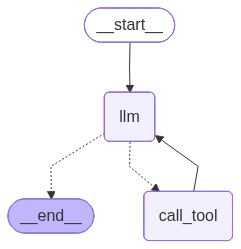

In [25]:
# LangGrph State Definition (Pydantic)
class AgentState(BaseModel):
    messages: Annotated[List[dict], operator.add] = Field(default_factory=list)

# Lang Graph Nodes
def call_model(state: AgentState):
    """Node to call the LLM
    """
    # Sends entire historical messages? Is it correct?
    response = call_llm(
        messages=state.messages, 
        tools=tool_declarations
    )
    return {"messages": [response.choices[0].message.dict()]}

def call_tool(state: AgentState):
    """Node to call a tool
    """
    last_msg = state.messages[-1]
    message_tool_outputs: List[Dict[str, Any]] = execute_tool_calls(messages=[last_msg])
    return {"messages": message_tool_outputs}
    
# 6. ROUTER & GRAPH
def router(state: AgentState) -> Literal["call_tool", "__end__"]:
    last_msg = state.messages[-1]
    return "call_tool" if last_msg.get("tool_calls") else "__end__"

builder = StateGraph(AgentState)
builder.add_node("llm", call_model)
builder.add_node("call_tool", call_tool)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", router)
builder.add_edge("call_tool", "llm")
app = builder.compile()

app

In [26]:
# 7. EXECUTION
inputs = {
    "messages": [
        {
            "role": "user",     # <--- Beware of the "role" used
            "content": "What are the top news headlines in AI from the last week?"
        }
    ]
}

for event in app.stream(inputs, stream_mode="values"):
    last_msg = event["messages"][-1]
    
    # Check if it's a dictionary (from our nodes) or a LiteLLM object
    role = last_msg.get("role", "assistant").upper() if isinstance(last_msg, dict) else last_msg.role.upper()
    
    # Robust display logic
    tool_calls = last_msg.get("tool_calls") if isinstance(last_msg, dict) else getattr(last_msg, "tool_calls", None)

    if tool_calls:
        # tool_calls[0] is an object, but function.arguments is a string
        first_call = tool_calls[0]
        # Handle both object-style and dict-style access
        args_str = first_call["function"]["arguments"] if isinstance(first_call, dict) else first_call.function.arguments
        params = json.loads(args_str)
        print(f"\n--- {role} (Calling Search with params: {params}) ---")
    else:
        content = last_msg.get("content") if isinstance(last_msg, dict) else getattr(last_msg, "content", "")
        print(f"\n--- {role} ---")
        if content:
            print(content)
        else:
            print("Processing...")


--- USER ---
What are the top news headlines in AI from the last week?


/var/folders/_4/8v285hqs45xfzk0l1nlr3yq40000gn/T/ipykernel_32859/2293917286.py:14: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  return {"messages": [response.choices[0].message.dict()]}



--- ASSISTANT (Calling Search with params: {'query': 'AI news', 'topic': 'news', 'search_depth': 'basic', 'time_range': 'week', 'max_results': 5}) ---

--- TOOL ---
Source: Wall-climbing robots swarm US Navy warships - Fox News
URL: https://www.foxnews.com/tech/ai-newsletter-wall-climbing-robots-swarm-us-navy-warships
Content: # Fox News AI Newsletter: Wall-climbing robots swarm US Navy warships. ## Welcome to Fox News’ Artificial Intelligence newsletter with the latest AI technology advancements. **TECH AT SEA:** **WATCH: wall-climbing robot swarms crawl US Navy warships as China's fleet surges** – *Fox News Digital reports on a new development in naval technology, featuring* *wall-climbing robot swarms* *that are crawling on U.S. Navy warships. **AIMING HIGH:** **FULL AUTONOMY: AI pilot technology advances towards military capability –** *Merlin CEO Matt George details how the company is using artificial intelligence to enable* *military and commercial aircraft* *to operate fully au